In [28]:
import pandas as pd
import numpy as np
import math
import torch.nn.functional as F
import torch.nn as nn
import torch
import os

In [29]:
df = pd.read_csv('/Users/admin/.cache/kagglehub/datasets/mnassrib/jena-climate/versions/1/jena_climate_2009_2016.csv')
df_subset = df.iloc[:, 1:]
new_df = df_subset.groupby(np.arange(len(df_subset)) // 6).mean()
new_df = (new_df - new_df.mean()) / new_df.std()

In [48]:
#encoding block
class Transformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.w_emb = nn.Linear(14,128,bias = True) #(14,128)
        self.register_buffer('p_e', pos_enc(d_model=128, seq_len=10))
        self.ffwd = nn.Sequential(nn.Linear(128,512,bias =True),nn.ReLU(),nn.Linear(512,128)) #32,10,128
        self.block = nn.Sequential(MultiHeadAttention(128),nn.LayerNorm(128),MultiHeadAttention(128),nn.LayerNorm(128))
        self.predictor_block= nn.Linear(128,14,bias = True)
        
    def forward(self,input):
        w_embd = self.w_emb(input)
        pos_embd = self.p_e
        x = w_embd + pos_embd# dim out is (32,10,128)
        out = self.block(x)# dim out is (32,10,128)
        out = self.ffwd(out) + out
        out_final = out[:,-1,:] # (32,128)
        logits = self.predictor_block(out_final) # 32,14
        return logits

    def prediction(self,input,future):
        pred= []
        for i in range(future):
            w_embd = self.w_emb(input)
            pos_embd = self.p_e
            x = w_embd + pos_embd# dim out is (32,10,128)
            out = self.block(x)# dim out is (32,10,128)
            out = self.ffwd(out) + out
            out_final = out[:,-1,:] # (32,128)
            logits = self.predictor_block(out_final) # 32,14
            pred.append(logits)
            logits = logits.unsqueeze(1)
            input = input[:, -32:, :]
            
        return pred

    

In [32]:

class MultiHeadAttention(nn.Module): #why is linear layer at the end required?
    def __init__(self, embd=128):
        super().__init__()  # fix: super.__init__() -> super().__init__()
        self.key = nn.Linear(embd, embd, bias=False)
        self.value = nn.Linear(embd, embd, bias=False)
        self.query = nn.Linear(embd, embd, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(10, 10)))  
        self.lin= nn.Linear(embd,embd,bias=True)

    def forward(self, x):  # x is of dim 32,10,128
        B, T, C = x.shape   # 32, 10, 128
        heads, head_dim = 8, 16

        wk = self.key(x).reshape(B, T, heads, head_dim).transpose(1, 2)    # 32,8,10,16
        wq = self.query(x).reshape(B, T, heads, head_dim).transpose(1, 2)  # 32,8,10,16
        val = self.value(x).reshape(B, T, heads, head_dim).transpose(1, 2) # 32,8,10,16

        wei = wq @ wk.transpose(-2, -1)  # 32,8,10,10
        wei = wei / (head_dim ** 0.5)    

        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)  # 32,8,10,10

        out = wei @ val  # 32,8,10,16
        out = out.transpose(1, 2).reshape(B, T, C)  # 32,10,128
        out = self.lin(out) + x 
        return out  # dim is (32,10,128)

    

In [33]:
import math

def pos_enc(d_model, seq_len):
    # seq_len is the number of positions to encode (e.g. 10)
    position = torch.arange(seq_len).unsqueeze(1).float()          
    i = torch.arange(0, d_model, 2).float()                        
    div_term = torch.exp(-i * math.log(10000.0) / d_model)         

    pe = torch.zeros(seq_len, d_model)
    pe[:, 0::2] = torch.sin(position * div_term)   
    pe[:, 1::2] = torch.cos(position * div_term)   

    return pe  

In [50]:
batch_size = 32
block_size = 10
data = torch.tensor(new_df[:50000].values, dtype=torch.float32)  
train_loss = []
for step in range(1000):  # number of training steps, not 32
    idx = torch.randint(0, len(data) - block_size - 1, (batch_size,))
    batch = torch.stack([data[i:i + block_size] for i in idx])      # (32,10,14)
    target = torch.stack([data[i + block_size] for i in idx])       # (32,14)
    loss = fw(batch, target)
    train_loss.append(loss.item())
    print(loss.item())

1.387014389038086
0.6310325264930725
0.34196633100509644
0.47128602862358093
0.37030625343322754
0.3594385087490082
0.297107458114624
0.1980595886707306
0.17866311967372894
0.17229832708835602
0.173040509223938
0.1998974233865738
0.12848955392837524
0.10516617447137833
0.0859057754278183
0.13294441998004913
0.1207079067826271
0.10621275752782822
0.17063875496387482
0.11184162646532059
0.0921780914068222
0.09593687206506729
0.09454984962940216
0.08951444923877716
0.05590131878852844
0.09759307652711868
0.0607181191444397
0.08382211625576019
0.052829496562480927
0.055962204933166504
0.08449327945709229
0.06668593734502792
0.06483088433742523
0.06911882013082504
0.08649028837680817
0.056526992470026016
0.04849454388022423
0.05335473269224167
0.03932344913482666
0.053099341690540314
0.060101840645074844
0.04796292260289192
0.07389461994171143
0.04834131523966789
0.04017559066414833
0.049270279705524445
0.03784927353262901
0.05212080478668213
0.03542908653616905
0.059300296008586884
0.04830

In [51]:
batch_size = 32
block_size = 10
data = torch.tensor(new_df[50000:60000].values, dtype=torch.float32)  
val_loss = []
for step in range(1000):  # number of training steps, not 32
    idx = torch.randint(0, len(data) - block_size - 1, (batch_size,))
    batch = torch.stack([data[i:i + block_size] for i in idx])      # (32,10,14)
    target = torch.stack([data[i + block_size] for i in idx])       # (32,14)
    loss = loss_calc(batch, target)
    val_loss.append(loss.item())
    print(loss.item())
    

0.045297618955373764
0.0512450635433197
0.026103496551513672
0.03731720894575119
0.03158563748002052
0.02673511393368244
0.028812123462557793
0.028741104528307915
0.04327844828367233
0.05315662547945976
0.06010892614722252
0.03933396190404892
0.03404630348086357
0.036478836089372635
0.027257641777396202
0.06769897043704987
0.026025013998150826
0.06886529177427292
0.03770080581307411
0.04900436848402023
0.03417257219552994
0.05011773854494095
0.042697060853242874
0.049047984182834625
0.03564555570483208
0.055013690143823624
0.02897820807993412
0.0357140451669693
0.05891884118318558
0.03520067036151886
0.040445808321237564
0.0324837751686573
0.041888684034347534
0.03524542227387428
0.0461883619427681
0.026854949072003365
0.06613387167453766
0.03944898769259453
0.04420366883277893
0.05007326602935791
0.05808492749929428
0.05231175199151039
0.07158147543668747
0.0574866458773613
0.03694123402237892
0.02547449804842472
0.04752940684556961
0.03923483565449715
0.043066490441560745
0.046280380

In [60]:
batch_size = 32
block_size = 10
data = torch.tensor(new_df[60000:].values, dtype=torch.float32)  
test_loss = []
rmse = []
for step in range(1000):  
    idx = torch.randint(0, len(data) - block_size - 1, (batch_size,))
    batch = torch.stack([data[i:i + block_size] for i in idx])      # (32,10,14)
    target = torch.stack([data[i + block_size] for i in idx])       # (32,14)
    loss = loss_calc(batch, target)
    test_loss.append(loss.item())
    rmse.append(torch.sqrt(loss).item())
    
print('mse loss', sum(test_loss)/len(test_loss))
print('rmse loss', sum(rmse)/len(rmse))


mse loss 0.03716471149027348
rmse loss 0.19076953030377627


In [61]:

data_array = new_df.iloc[-10:].values
data = torch.tensor(data_array, dtype=torch.float32).unsqueeze(0) 
preds = model1.prediction(data, future=10)
print(preds)

[tensor([[ 1.4021, -1.6493, -1.7505, -2.1449, -0.3357, -1.1827, -1.5324, -0.4699,
         -1.5424, -1.5619,  1.9975, -0.0700, -0.0286, -0.0195]],
       grad_fn=<AddmmBackward0>), tensor([[ 1.4021, -1.6493, -1.7505, -2.1449, -0.3357, -1.1827, -1.5324, -0.4699,
         -1.5424, -1.5619,  1.9975, -0.0700, -0.0286, -0.0195]],
       grad_fn=<AddmmBackward0>), tensor([[ 1.4021, -1.6493, -1.7505, -2.1449, -0.3357, -1.1827, -1.5324, -0.4699,
         -1.5424, -1.5619,  1.9975, -0.0700, -0.0286, -0.0195]],
       grad_fn=<AddmmBackward0>), tensor([[ 1.4021, -1.6493, -1.7505, -2.1449, -0.3357, -1.1827, -1.5324, -0.4699,
         -1.5424, -1.5619,  1.9975, -0.0700, -0.0286, -0.0195]],
       grad_fn=<AddmmBackward0>), tensor([[ 1.4021, -1.6493, -1.7505, -2.1449, -0.3357, -1.1827, -1.5324, -0.4699,
         -1.5424, -1.5619,  1.9975, -0.0700, -0.0286, -0.0195]],
       grad_fn=<AddmmBackward0>), tensor([[ 1.4021, -1.6493, -1.7505, -2.1449, -0.3357, -1.1827, -1.5324, -0.4699,
         -1.5424, 

In [49]:
model1 = Transformer()
optimiser = torch.optim.AdamW(model1.parameters(), lr=0.001)

In [36]:
def fw(batch,target): #32,10,14, 32,1,14
    optimiser.zero_grad()
    logits = model1(batch) #32,1,14
    loss = F.mse_loss(logits,target)
    loss.backward()
    optimiser.step()
    return loss

def loss_calc(batch,target):
    logits = model1(batch) #32,1,14
    loss = F.mse_loss(logits,target)
    return loss

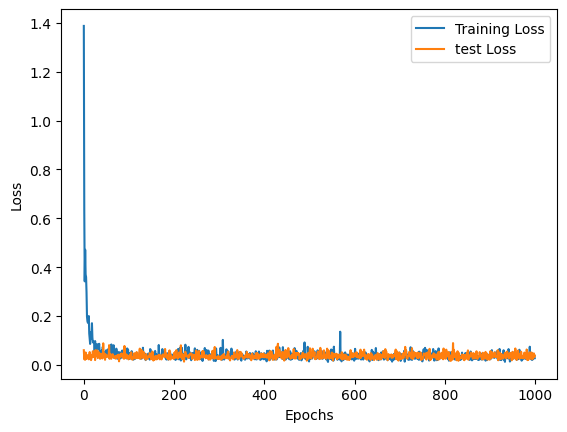

In [62]:
import matplotlib.pyplot as plt
plt.plot(train_loss, label='Training Loss')
#plt.plot(val_loss, label='Validation Loss')
plt.plot(test_loss, label='test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

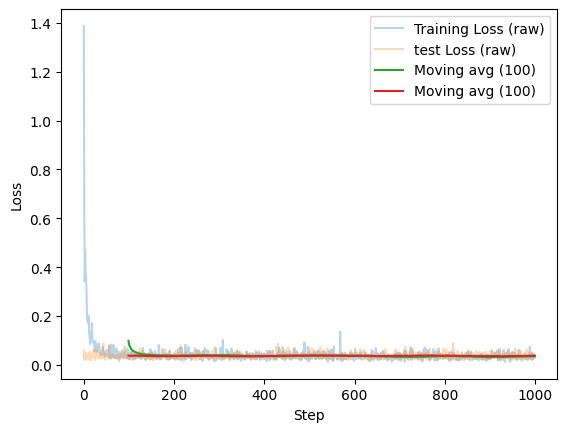

In [64]:
import matplotlib.pyplot as plt
import numpy as np

window = 100
smoothed_train = np.convolve(train_loss, np.ones(window)/window, mode='valid')
#smoothed_val = np.convolve(val_loss, np.ones(window)/window, mode='valid')
smoothed_test = np.convolve(test_loss, np.ones(window)/window, mode='valid')

plt.plot(train_loss, alpha=0.3, label='Training Loss (raw)')
#plt.plot(val_loss, alpha=0.3, label='Validation Loss (raw)')
plt.plot(test_loss, alpha=0.3, label='test Loss (raw)')
plt.plot(range(window-1, len(train_loss)), smoothed_train, label=f'Moving avg ({window})')
#plt.plot(range(window-1, len(val_loss)), smoothed_val, label=f'Moving avg ({window})')
plt.plot(range(window-1, len(test_loss)), smoothed_test, label=f'Moving avg ({window})')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [66]:
torch.save(model1.state_dict(), 'base_ml_task_3.pth')